<a href="https://colab.research.google.com/github/JorgeRf07/Diplomado-Redes-Neuronales-Artificiales/blob/main/Pronostico_Clase7_Temp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import pandas as pd
URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
df = pd.read_csv(URL)

In [18]:
df.head()

,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3650 non-null   object 
 1   Temp    3650 non-null   float64
dtypes: float64(1), object(1)
memory usage: 57.2+ KB


In [20]:
#Preprocesameinto
df.columns = ["Fecha","Temperatura"]
datos = df.dropna() #dropna sirve para eliminar filas vacias
#convertir fecha a un dato date
datos["Fecha"] = pd.to_datetime(datos["Fecha"])
print(datos.head())
datos.info()

       Fecha  Temperatura
0 1981-01-01         20.7
1 1981-01-02         17.9
2 1981-01-03         18.8
3 1981-01-04         14.6
4 1981-01-05         15.8
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Fecha        3650 non-null   datetime64[ns]
 1   Temperatura  3650 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 57.2 KB


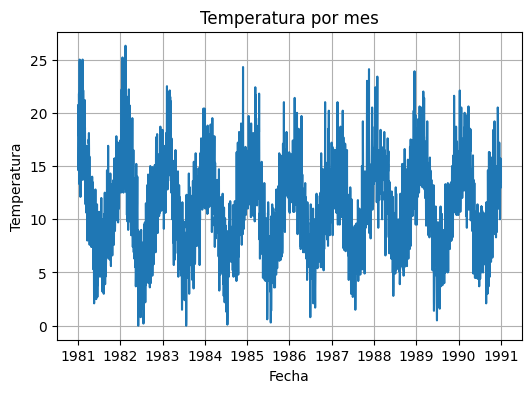

In [21]:
import matplotlib.pyplot as plt
plt.figure(figsize = (6,4))
plt.plot(datos["Fecha"],datos["Temperatura"])
plt.title("Temperatura por mes")
plt.xlabel("Fecha")
plt.ylabel("Temperatura")
plt.grid() #Agrega grillas
plt.show()

In [22]:
#Normalizacion de datos mantener datos entre 0 y 1 y estandarizacion que todos los datos se mantuvieran en un mismo rango
#libreria
from sklearn.preprocessing import MinMaxScaler
"""
X_norm = x-xmin/xmax-xmin x pertenece a los reales entre 0 y 1
"""
serie = datos["Temperatura"].values.reshape(-1,1)
#print(serie)
scaler = MinMaxScaler(feature_range=(0,1))
serie_norm = scaler.fit_transform(serie)
print(serie_norm[:10])

[[0.78707224]
 [0.68060837]
 [0.7148289 ]
 [0.55513308]
 [0.60076046]
 [0.60076046]
 [0.60076046]
 [0.66159696]
 [0.82889734]
 [0.76045627]]


In [23]:
import numpy as np
#Creamos las ventanas temporales
#para x = 12 meses anteriores
#para y = ultimo mes (siguiente)
#Crear la ventana deslizante
def ventana_deslizante(datos, ventana=12):
  x = []
  y = []
  for i in range(len(datos)-ventana):
    #datos anteriores
    x.append(datos[i:i+ventana])
    #dato futuro
    y.append(datos[i+ventana])
  return np.array(x), np.array(y)

In [24]:
ventana = 12
X,y = ventana_deslizante(serie_norm,ventana)
print(X.shape)
print(y.shape)

(3638, 12, 1)
(3638, 1)


In [25]:
#LA DIVISION DE DATOS NO PUEDE SER ALEATORIA
division = int(len(X)*0.8) #tomamos el 80% de los datos
X_train = X[:division]
print(X_train)
X_test = X[division:]
print(X_test)
y_train = y[:division]
print(y_train)
y_test = y[division:]
print(y_test)

[[[0.78707224]
  [0.68060837]
  [0.7148289 ]
  ...
  [0.76045627]
  [0.61596958]
  [0.50570342]]

 [[0.68060837]
  [0.7148289 ]
  [0.55513308]
  ...
  [0.61596958]
  [0.50570342]
  [0.63498099]]

 [[0.7148289 ]
  [0.55513308]
  [0.60076046]
  ...
  [0.50570342]
  [0.63498099]
  [0.81749049]]

 ...

 [[0.66539924]
  [0.56653992]
  [0.51711027]
  ...
  [0.4904943 ]
  [0.4904943 ]
  [0.56273764]]

 [[0.56653992]
  [0.51711027]
  [0.45247148]
  ...
  [0.4904943 ]
  [0.56273764]
  [0.53612167]]

 [[0.51711027]
  [0.45247148]
  [0.57794677]
  ...
  [0.56273764]
  [0.53612167]
  [0.54372624]]]
[[[0.45247148]
  [0.57794677]
  [0.65779468]
  ...
  [0.53612167]
  [0.54372624]
  [0.66159696]]

 [[0.57794677]
  [0.65779468]
  [0.75285171]
  ...
  [0.54372624]
  [0.66159696]
  [0.70342205]]

 [[0.65779468]
  [0.75285171]
  [0.60076046]
  ...
  [0.66159696]
  [0.70342205]
  [0.63878327]]

 ...

 [[0.52851711]
  [0.6539924 ]
  [0.55893536]
  ...
  [0.55513308]
  [0.53231939]
  [0.51711027]]

 [[0.653

In [26]:
#Creamos la red
#LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
modelo = Sequential()
modelo.add(
    LSTM(50,activation="tanh", input_shape = (ventana,1), return_sequences = True)
) #primer capa
modelo.add(LSTM(30,activation="tanh")) #segunda capa
modelo.add(Dense(1)) #Capa de salida, indica la prediccion de la salida (1)

modelo.compile(optimizer="adam",loss = 'mse')
modelo.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 12, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 30)             │         9,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,151 (78.71 KB)

 Trainable params: 20,151 (78.71 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
historial = modelo.fit(X_train,y_train, epochs = 100, batch_size = 8,validation_split=0.1,verbose=1)

Epoch 1/100
328/328 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0147 - val_loss: 0.0107
Epoch 2/100
328/328 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0123 - val_loss: 0.0105
Epoch 3/100
328/328 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0115 - val_loss: 0.0104
Epoch 4/100
328/328 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0103 - val_loss: 0.0090
Epoch 5/100
328/328 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0094 - val_loss: 0.0090
Epoch 6/100
328/328 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0094 - val_loss: 0.0092
Epoch 7/100
328/328 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0092 - val_loss: 0.0094
Epoch 8/100
328/328 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0093 - val_loss: 0.0092
Epoch 9/100
328/328 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0092 - val_loss: 0.0098
Epoch 10/100
328/328 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0092 - val_loss: 0.0091
Epoch 11/100
328/328 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0093 - val_loss: 0.0091
Epoch 12/100
328/328 ━━━━━━━━━━━━━━━━━━

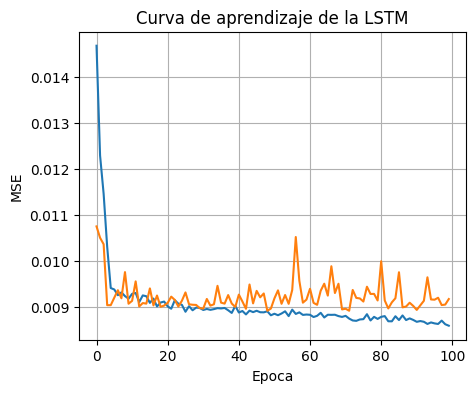

In [28]:
#graficar el aprendizaje
plt.figure(figsize=(5,4))

plt.plot(historial.history["loss"],label="Entrenamiento")
plt.plot(historial.history["val_loss"],label="Validacion")
plt.xlabel("Epoca")
plt.ylabel("MSE")
plt.title("Curva de aprendizaje de la LSTM")
plt.grid()
plt.show()

In [29]:
prediccion = modelo.predict(X_test)
#Comparamos el valor real con la prediccion
prediccion_real = scaler.inverse_transform(prediccion)
y_test_real = scaler.inverse_transform(y_test.reshape(-1,1))
resultados = pd.DataFrame({
    "Real": y_test_real.flatten(),
    "Pronostico": prediccion_real.flatten()
})

print(resultados)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
     Real  Pronostico
0    18.5   15.401724
1    16.8   15.650653
2    11.5   15.000219
3     9.5   12.419828
4    12.2   11.254169
..    ...         ...
723  14.0   13.629362
724  13.6   13.298518
725  13.5   13.136122
726  15.7   13.248205
727  13.0   14.323024

[728 rows x 2 columns]


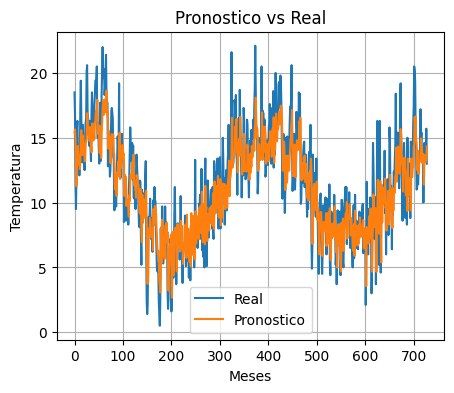

In [30]:
#Graficar pronopstico vs realidad
plt.figure(figsize=(5,4))
plt.plot(y_test_real,label="Real")
plt.plot(prediccion_real,label="Pronostico")
plt.xlabel("Meses")
plt.ylabel("Temperatura")
plt.title("Pronostico vs Real")
plt.grid()
plt.legend()
plt.show()

In [31]:
#calculamos las metricas
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
mae = mean_absolute_error(y_test_real,prediccion_real)
mse = mean_squared_error(y_test_real,prediccion_real)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_real,prediccion_real)
print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)
print("R2:",r2)
#

MAE: 1.7795983748776574
MSE: 5.083991563919143
RMSE: 2.254770845101369
R2: 0.6978826610841431


In [32]:
#pronosticar el siguiente el siguiente mes
ultimos = serie_norm[-ventana:]
entrada = ultimos.reshape(1,12,1)
futuro_norm = modelo.predict(entrada)
futuro = scaler.inverse_transform(futuro_norm)
print("Temperatura pronosticada:",futuro[0][0]) #siguiente mes
#pronosticar proximos 12 meses
secuencia = serie_norm[-12:].copy()
pronosticos = []
for i in range(12):
  entrada = secuencia.reshape(1,12,1)
  pred = modelo.predict(entrada)
  pronosticos.append(pred[0][0])
  secuencia = np.append(secuencia,pred)
  secuencia = secuencia[1:]
pronosticos

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Temperatura pronosticada: 12.760349
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


[np.float32(0.48518437),
 np.float32(0.4870363),
 np.float32(0.4920283),
 np.float32(0.49302042),
 np.float32(0.4872679),
 np.float32(0.4855265),
 np.float32(0.48506075),
 np.float32(0.48251194),
 np.float32(0.47883248),
 np.float32(0.47485417),
 np.float32(0.47283167),
 np.float32(0.46826363)]